# Toxicity Worker Inference Research
This notebook demonstrates how to load the local `DetoxifyOnnxAdapter` and run inference on sample texts to verify toxicity scoring.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../../../../packages/python/toxicity-worker/src'))

from infra.adapters.detoxify_onnx_adapter import DetoxifyOnnxAdapter
from core.domain.types import ToxicityInput
from core.domain.service import score_toxicity
import time
import pandas as pd
import matplotlib.pyplot as plt

Initialize the adapter with the default unitary/toxic-bert model:

In [2]:
adapter = DetoxifyOnnxAdapter()
print(f"Loaded model: {adapter.model_id}")

Loaded model: unitary/toxic-bert


Tokenize and score a standard sample sentence (under 510 tokens) and plot the category distributions:

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{
    "name": "toxicity.tokenize",
    "context": {
        "trace_id": "0x78c96f466715dec6d743f844d3cf2f87",
        "span_id": "0x9f7b89a74a7929b7",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x27aa47a885a51f80",
    "start_time": "2026-06-02T11:42:04.510934Z",
    "end_time": "2026-06-02T11:42:09.777907Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "output.token_count": 11
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


`torch_dtype` is deprecated! Use `dtype` instead!


/usr/local/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  inverted_mask = torch.tensor(1.0, dtype=dtype) - expanded_mask


{
    "name": "model_inference",
    "context": {
        "trace_id": "0x78c96f466715dec6d743f844d3cf2f87",
        "span_id": "0x1d0d18bdd8ba33e7",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x27aa47a885a51f80",
    "start_time": "2026-06-02T11:42:09.779753Z",
    "end_time": "2026-06-02T11:42:39.898768Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "score_toxicity",
    "context": {
        "trace_id": "0x78c96f466715dec6d743f844d3cf2f87",
        "span_id": "0x27aa47a885a51f80",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-06-02T11:42:04.510690Z",
    "end_time": "2026-06-02T11:42:39.900987Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "input.text_length": 59,
        "output.score": 0.0009134248830378056
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


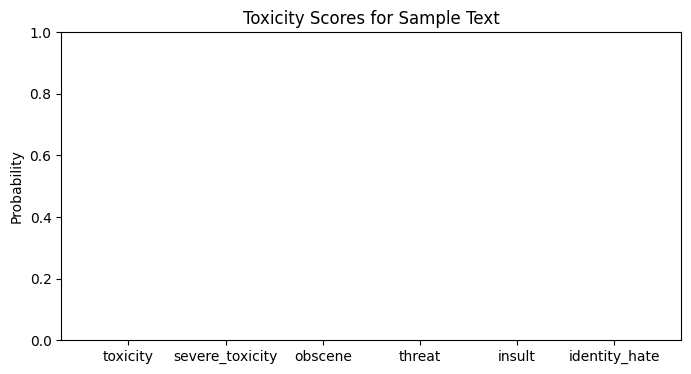

          Category  Probability
0         toxicity     0.000913
1  severe_toxicity     0.000115
2          obscene     0.000224
3           threat     0.000115
4           insult     0.000180
5    identity_hate     0.000134


In [3]:
sample_text = "This is an awesome day and everything is working perfectly!"
result = score_toxicity(input=ToxicityInput(text=sample_text), scorer=adapter, trace_id=None, span_id=None)

scores_dict = result.scores.__dict__
df_scores = pd.DataFrame(list(scores_dict.items()), columns=["Category", "Probability"])

plt.figure(figsize=(8, 4))
plt.bar(df_scores["Category"], df_scores["Probability"], color="royalblue")
plt.title("Toxicity Scores for Sample Text")
plt.ylabel("Probability")
plt.ylim(0, 1.0)
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/toxicity_scores.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_scores)

Perform latency benchmarking across various token lengths, showing the step change when transitioning from single-pass (< 510 tokens) to dual-pass (> 510 tokens):

{
    "name": "toxicity.tokenize",
    "context": {
        "trace_id": "0x809abfd75a19d3cdb718f373e0be5ef8",
        "span_id": "0x0ff472dd54147df0",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0xe364572bb99068da",
    "start_time": "2026-06-02T11:42:40.336132Z",
    "end_time": "2026-06-02T11:42:40.336524Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "output.token_count": 10
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "model_inference",
    "context": {
        "trace_id": "0x809abfd75a19d3cdb718f373e0be5ef8",
        "span_id": "0xcbd596dbc8fa4172",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0xe364572bb99068da",
    "start_time": "2026-06-02T11:42:40.339972Z",
    "end_time": "2026-06-02T11:42:40.394741Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "score_toxicity",
    "context": {
        "trace_id": "0x809abfd75a19d3cdb718f373e0be5ef8",
        "span_id": "0xe364572bb99068da",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-06-02T11:42:40.336000Z",
    "end_time": "2026-06-02T11:42:40.396328Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "input.text_length": 50,
        "output.score": 0.0009399053524248302
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "toxicity.tokenize",
    "context": {
        "trace_id": "0x1c53a20c98e61b4a93171a208b531b7b",
        "span_id": "0x60581cb7a1c56e33",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x10944a78da41925c",
    "start_time": "2026-06-02T11:42:40.397794Z",
    "end_time": "2026-06-02T11:42:40.398377Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "output.token_count": 50
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "model_inference",
    "context": {
        "trace_id": "0x1c53a20c98e61b4a93171a208b531b7b",
        "span_id": "0x3166358376ce800a",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x10944a78da41925c",
    "start_time": "2026-06-02T11:42:40.401517Z",
    "end_time": "2026-06-02T11:42:40.573444Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


...

{
    "name": "model_inference",
    "context": {
        "trace_id": "0x5abeca9980dd370cea87814d3e73d57e",
        "span_id": "0x951db09ba97b6603",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0xceb192c4667a6933",
    "start_time": "2026-06-02T11:43:02.990554Z",
    "end_time": "2026-06-02T11:43:06.444024Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "score_toxicity",
    "context": {
        "trace_id": "0x5abeca9980dd370cea87814d3e73d57e",
        "span_id": "0xceb192c4667a6933",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-06-02T11:43:02.978558Z",
    "end_time": "2026-06-02T11:43:06.445155Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "input.text_length": 4500,
        "output.score": 0.016099391505122185,
        "output.strategy": "max_of_two_passes"
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "toxicity.tokenize",
    "context": {
        "trace_id": "0x37d6a205247d79da36c9441cbbb73684",
        "span_id": "0xb171aea559948811",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x31066748a29aef4f",
    "start_time": "2026-06-02T11:43:06.446493Z",
    "end_time": "2026-06-02T11:43:06.453350Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "output.token_count": 1000
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "model_inference",
    "context": {
        "trace_id": "0x37d6a205247d79da36c9441cbbb73684",
        "span_id": "0x4953a9357eea80e4",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x31066748a29aef4f",
    "start_time": "2026-06-02T11:43:06.454667Z",
    "end_time": "2026-06-02T11:43:09.600574Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


{
    "name": "score_toxicity",
    "context": {
        "trace_id": "0x37d6a205247d79da36c9441cbbb73684",
        "span_id": "0x31066748a29aef4f",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-06-02T11:43:06.446378Z",
    "end_time": "2026-06-02T11:43:09.608257Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "input.text_length": 5000,
        "output.score": 0.016099391505122185,
        "output.strategy": "max_of_two_passes"
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.42.1",
            "service.name": "toxicity-worker",
            "service.version": "0.1.0",
            "deployment.env": "dev"
        },
        "schema_url": ""
    }
}


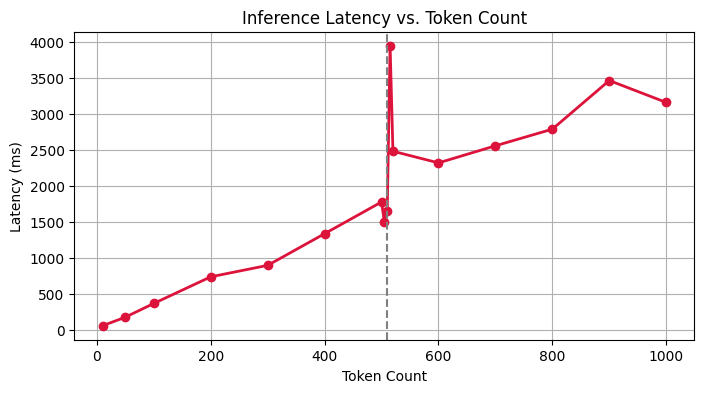

    TokenCount    LatencyMs
0           10    61.633775
1           50   180.583260
2          100   371.374360
3          200   741.095591
4          300   900.142329
5          400  1340.374025
6          500  1780.822711
7          505  1497.962589
8          510  1654.714987
9          515  3951.165973
10         520  2485.371709
11         600  2323.778932
12         700  2561.115033
13         800  2792.139540
14         900  3467.914537
15        1000  3163.319482


In [4]:
token_counts = [10, 50, 100, 200, 300, 400, 500, 505, 510, 515, 520, 600, 700, 800, 900, 1000]
latencies = []

for count in token_counts:
    text = "word " * count
    
    start_time = time.perf_counter()
    _ = score_toxicity(input=ToxicityInput(text=text), scorer=adapter, trace_id=None, span_id=None)
    end_time = time.perf_counter()
    
    latency_ms = (end_time - start_time) * 1000
    latencies.append(latency_ms)

df_latency = pd.DataFrame({"TokenCount": token_counts, "LatencyMs": latencies})

plt.figure(figsize=(8, 4))
plt.plot(df_latency["TokenCount"], df_latency["LatencyMs"], marker="o", color="crimson", linewidth=2)
plt.axvline(x=510, color="gray", linestyle="--")
plt.title("Inference Latency vs. Token Count")
plt.xlabel("Token Count")
plt.ylabel("Latency (ms)")
plt.grid(True)
plt.savefig("outputs/latency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_latency)